# Manuscript revision figures

Figures generated in response to reviewer comments.

## Comment 1

> In lines 168-170, the manuscript states the data domain is 10-70N/150-40W (ERA5 input), but Table 3 ("domain wide skill") appears to only cover the West Coast offshore region shown in Figure 2.

This figure shows both domains - the full ERA5 input domain and the West Coast evaluation domain used for `pred.nc`/`gt.nc` and Table 3 - plus the two evaluation sites (Humboldt and Morro buoy/lidar locations).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%load_ext autoreload
%autoreload 2
import xarray as xr
import pandas as pd
import numpy as np
from yllib.function import myfunc
from yllib.plot import plot_map
from cartopy import crs as ccrs
import matplotlib.pyplot as plt
import matplotlib as mpl
%config InlineBackend.figure_format='retina'

In [2]:
# Domain definitions (lon in -180..180)

# ERA5 input domain, manuscript lines 168-170: 10-70N, 150-40W
era5_domain = dict(lon_min=-150, lon_max=-40, lat_min=10, lat_max=70)

# West Coast evaluation domain: actual extent of pred.nc / gt.nc / mask_4D.nc
# (lat 29.721663-48.909824, lon -132.1083 to -116.76309)
eval_domain = dict(lon_min=-132.1083, lon_max=-116.76309, lat_min=29.721663, lat_max=48.909824)

# Evaluation sites: [lon, lat]
sites = {
    'Humboldt': [-124.5907, 40.97],
    'Morro': [-121.8581, 35.7107],
}

# Offshore analysis mask within the evaluation domain (mask_4D.nc).
# The HRRR grid actually analyzed for Table 3 is the ocean fraction of
# this mask, not the full eval_domain rectangle.
mask_ds = xr.open_dataset('mask_4D.nc')
offshore_mask = mask_ds['mask'].isel(hour=0, channel=0)
mask_lat = mask_ds['lat'].values
mask_lon = mask_ds['lon'].values
mask_lon = np.where(mask_lon > 180, mask_lon - 360, mask_lon)

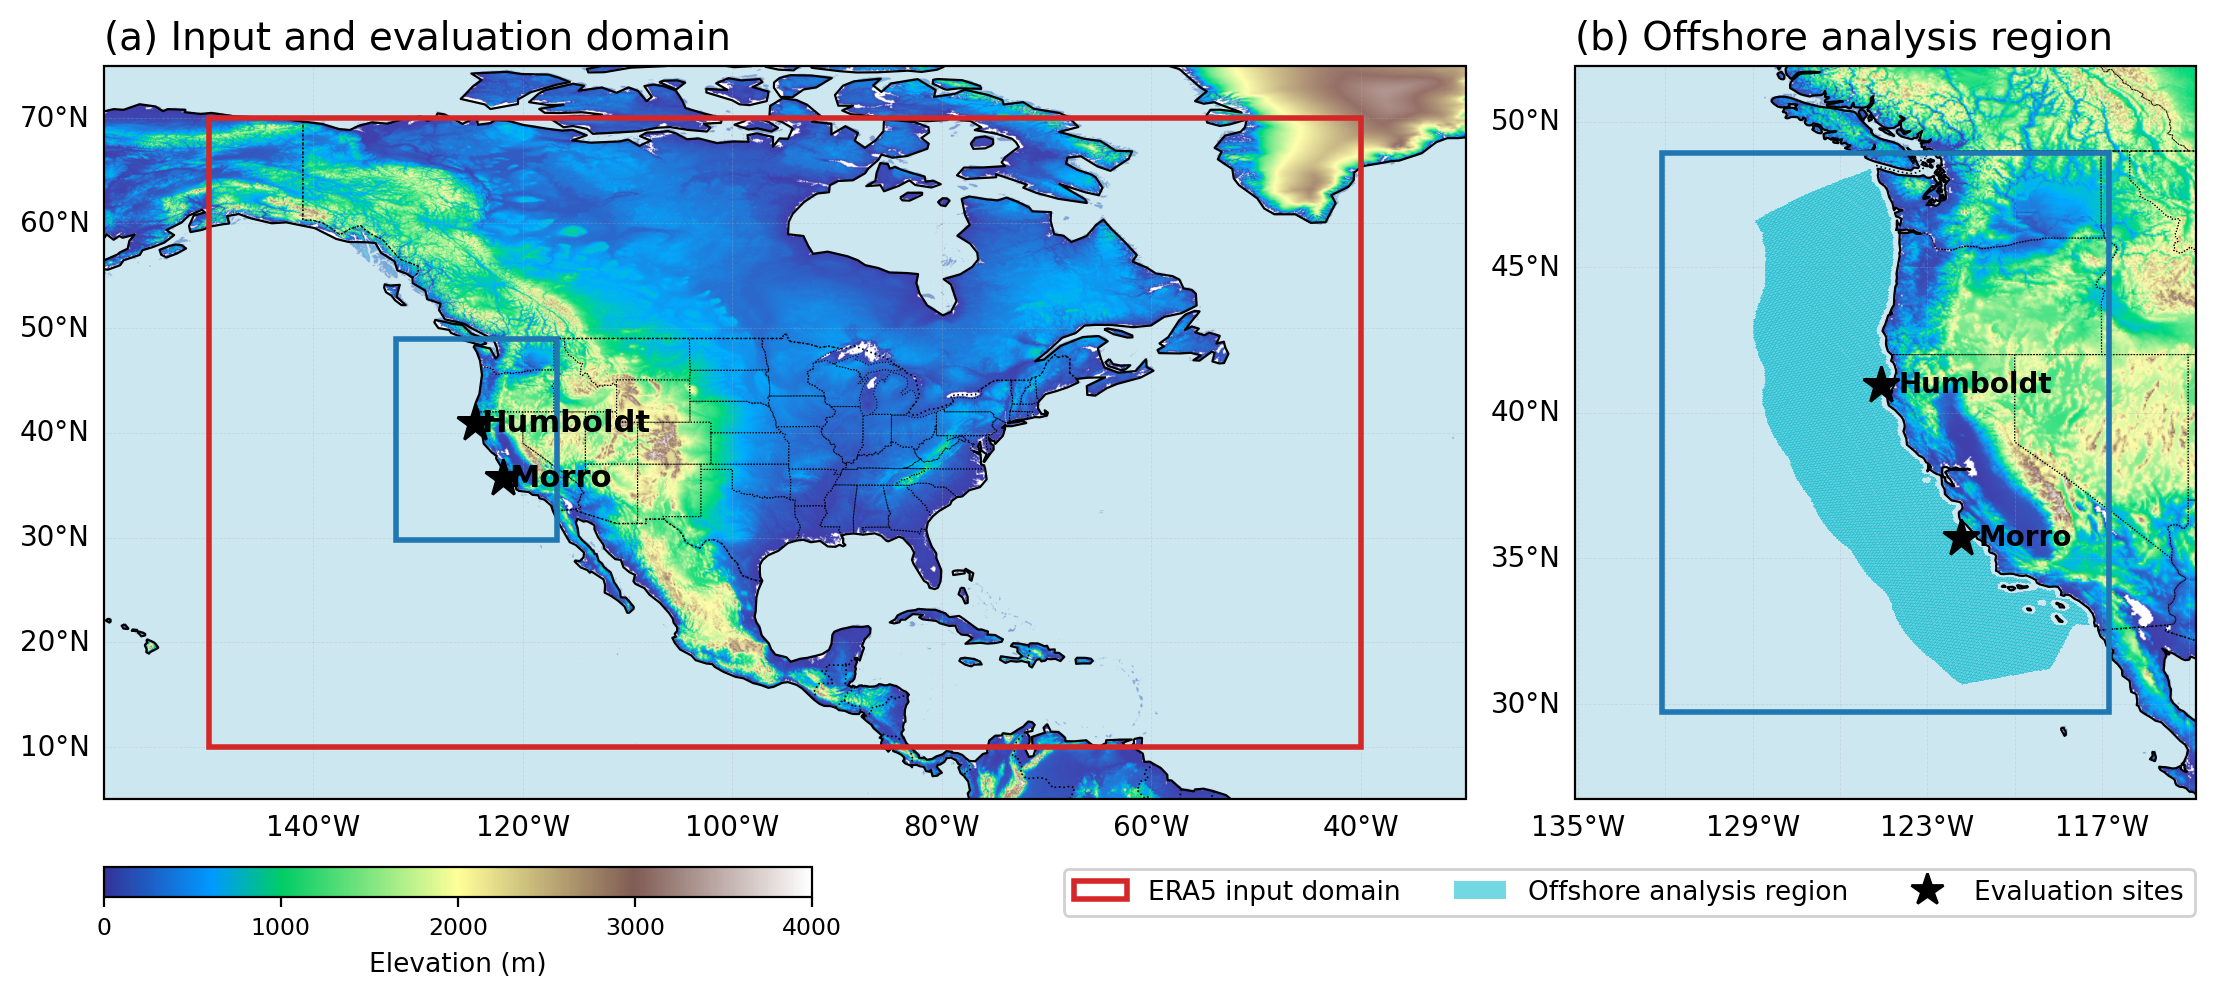

In [3]:
from matplotlib.colors import LightSource, Normalize

pad = 3.0
panel_a_extent = [-160, -30, 5, 75]
panel_b_extent = [eval_domain['lon_min'] - pad, eval_domain['lon_max'] + pad,
                   eval_domain['lat_min'] - pad, eval_domain['lat_max'] + pad]

def extent_ratio(extent):
    return (extent[1] - extent[0]) / (extent[3] - extent[2])

width_ratios = [extent_ratio(panel_a_extent), extent_ratio(panel_b_extent)]

# Load ETOPO1 once, subsetted to the region covered by both panels
_etopo_ds  = xr.open_dataset('/global/u2/y/yeliu/yllib/ETOPO/ETOPO1_Ice_g_gmt4.0.05.nc4')
_etopo_sub = _etopo_ds['z'].sel(lon=slice(-165, -25), lat=slice(3, 77))
_etopo_z   = _etopo_sub.values.astype(float)          # (lat, lon)
_etopo_lon = _etopo_sub['lon'].values
_etopo_lat = _etopo_sub['lat'].values

_ls        = LightSource(azdeg=315, altdeg=45)
_topo_norm = Normalize(vmin=0, vmax=4000)

def add_topography(ax):
    """Hillshaded ETOPO1 land topography overlaid on a PlateCarree axis.
    Ocean pixels are transparent so the OCEAN feature shows through."""
    land = np.where(_etopo_z > 0, _etopo_z, np.nan)
    shade_input = np.where(np.isnan(land), 0.0, land)
    rgb = _ls.shade(
        shade_input,
        cmap=plt.cm.terrain,
        norm=_topo_norm,
        vert_exag=5e-4,
        blend_mode='soft',
    )
    rgb[np.isnan(land), 3] = 0.0
    ax.imshow(
        rgb, origin='lower',
        extent=[_etopo_lon[0], _etopo_lon[-1], _etopo_lat[0], _etopo_lat[-1]],
        transform=ccrs.PlateCarree(), zorder=1, interpolation='bilinear',
    )

def domain_box(d, **kwargs):
    return mpatches.Rectangle(
        (d['lon_min'], d['lat_min']),
        d['lon_max'] - d['lon_min'],
        d['lat_max'] - d['lat_min'],
        transform=ccrs.PlateCarree(),
        fill=False,
        **kwargs,
    )

def add_basemap(ax):
    # LAND fill omitted — add_topography() provides land background
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.6, zorder=2)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.6, zorder=3)
    ax.add_feature(cfeature.STATES, linestyle=':', linewidth=0.4, zorder=3)

def add_sites(ax, fontsize=11):
    for name, (lon, lat) in sites.items():
        ax.plot(lon, lat, marker='*', color='black', markersize=14, transform=ccrs.PlateCarree(), zorder=7)
        ax.text(lon + 0.6, lat, name, transform=ccrs.PlateCarree(), fontsize=fontsize, fontweight='bold',
                va='center', zorder=7)

fig, axs = plt.subplots(
    1, 2, figsize=(13.5, 7),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'width_ratios': width_ratios, 'wspace': 0.11},
)

# Panel (a): full ERA5 input domain vs. West Coast evaluation domain
ax = axs[0]
ax.set_extent(panel_a_extent, crs=ccrs.PlateCarree())
add_topography(ax)
add_basemap(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax.add_patch(domain_box(era5_domain, edgecolor='tab:red', linewidth=2.0, linestyle='-', zorder=5))
ax.add_patch(domain_box(eval_domain, edgecolor='tab:blue', linewidth=2.0, zorder=6))
add_sites(ax)
ax.set_title('(a) Input and evaluation domain', loc='left', fontsize=14)

# Panel (b): zoom on the West Coast evaluation domain
ax = axs[1]
ax.set_extent(panel_b_extent, crs=ccrs.PlateCarree())
add_topography(ax)
add_basemap(ax)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.3, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

ax.add_patch(domain_box(eval_domain, edgecolor='tab:blue', linewidth=2.0, zorder=6))

offshore_plot = np.where(offshore_mask.values == 1, 1, np.nan)
ax.pcolormesh(
    mask_lon, mask_lat, offshore_plot,
    transform=ccrs.PlateCarree(), cmap=mpl.colors.ListedColormap(['tab:cyan']),
    shading='auto', alpha=0.6, zorder=4,
)

add_sites(ax, fontsize=10)
ax.set_title('(b) Offshore analysis region', loc='left', fontsize=14)

# Get actual panel positions after layout is computed
fig.canvas.draw()
panels_bottom = min(ax.get_position().y0 for ax in axs)
ax0_pos = axs[0].get_position()

# Topography colorbar: horizontal, lower-left (below left panel)
cax_topo = fig.add_axes([
    ax0_pos.x0,
    panels_bottom - 0.07,
    ax0_pos.width * 0.52,
    0.022,
])
sm = mpl.cm.ScalarMappable(cmap=plt.cm.terrain, norm=_topo_norm)
sm.set_array([])
cb_topo = fig.colorbar(sm, cax=cax_topo, orientation='horizontal',
                       ticks=[0, 1000, 2000, 3000, 4000])
cb_topo.set_label('Elevation (m)', fontsize=9.5)
cb_topo.ax.tick_params(labelsize=8.5)

# Main legend: lower-right
legend_handles = [
    mpatches.Patch(edgecolor='tab:red', facecolor='none', linewidth=2.0, linestyle='-', label='ERA5 input domain'),
    mpatches.Patch(facecolor='tab:cyan', edgecolor='none', alpha=0.6, label='Offshore analysis region'),
    plt.Line2D([0], [0], marker='*', color='black', linestyle='None', markersize=12, label='Evaluation sites'),
]
fig.legend(handles=legend_handles, loc='upper center', ncol=3,
           bbox_to_anchor=(0.69, panels_bottom - 0.04), bbox_transform=fig.transFigure,
           fontsize=9.5, framealpha=0.9)

plt.savefig('figure_domain_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Comment 2

> In Line 328, you defined an accuracy score in which you verify 4 different wind speed categories into a combined score. Machine learning models tend not to perform well for extreme events. With the combined accuracy score, it is difficult to tell if the machine learning method performed well or not in the high wind speed category. It would be good to verify each wind speed category separately and compute error metrics such as critical success index, false alarm ratio, bias, etc.

`calc_accuracy.py` and its existing outputs (`statistics/accuracy.*.nc`) are left untouched. A new script, `calc_statistics.py`, computes per-category contingency-table verification (POD, FAR, CSI, Frequency Bias) using the manuscript's wind speed categories (0-3, 3-11, 11-25, >25 m/s), pooled over all valid hours and grid cells in the offshore evaluation region (see Comment 1), for each experiment and season. Outputs: `statistics/categorical_verification.<expr>.<season>.csv`.

- POD (probability of detection) = hits / (hits + misses)
- FAR (false alarm ratio) = false alarms / (hits + false alarms)
- CSI (critical success index) = hits / (hits + misses + false alarms)
- Frequency Bias = (hits + false alarms) / (hits + misses)

In [4]:
import os
import glob

csv_files = sorted(glob.glob('statistics/categorical_verification.*.csv'))

def parse_name(path):
    base = os.path.basename(path)
    middle = base[len('categorical_verification.'):-len('.csv')]
    expr, season = middle.rsplit('.', 1)
    return expr, season

records = []
for f in csv_files:
    expr, season = parse_name(f)
    df = pd.read_csv(f)
    df['expr'] = expr
    df['season'] = season
    records.append(df)
verification_df = pd.concat(records, ignore_index=True)

category_order = ['0-3', '3-11', '11-25', '>25']
expr_order = ['lisa3.1', 'lisa3.1_4hr', 'unet']
verification_df['category'] = pd.Categorical(verification_df['category'], categories=category_order, ordered=True)
verification_df['expr'] = pd.Categorical(verification_df['expr'], categories=expr_order, ordered=True)

verification_df.shape

(60, 17)

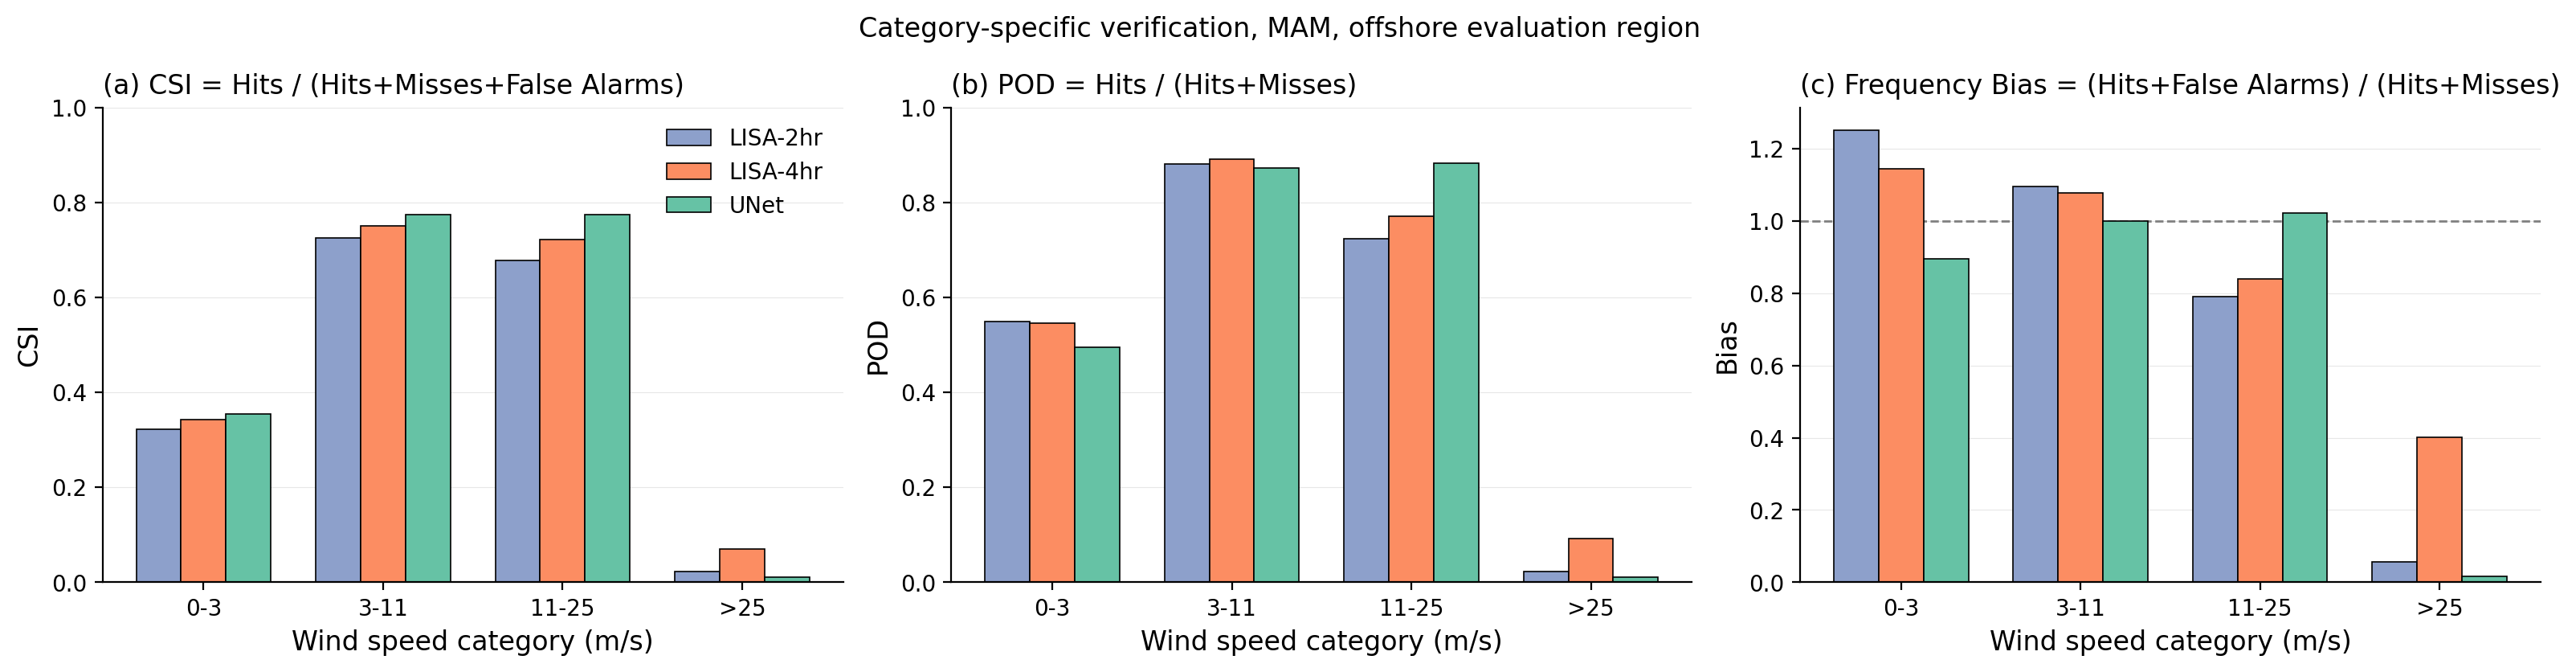

In [6]:
# Figure: CSI, POD, and Frequency Bias by wind speed category, one bar
# group per experiment (ANN season). The combined accuracy score
# (~0.81-0.85 across experiments) masks the fact that skill collapses
# (and the model under-forecasts, Bias << 1) in the >25 m/s category,
# shaded red below.
ann = verification_df[verification_df['season'] == 'MAM']
# ColorBrewer Set2 - colorblind-safe, lighter/softer than Okabe-Ito, common in journal figures.
colors = {'lisa3.1': '#8da0cb', 'lisa3.1_4hr': '#fc8d62', 'unet': '#66c2a5'}
labels = {'lisa3.1': 'LISA-2hr', 'lisa3.1_4hr': 'LISA-4hr', 'unet': 'UNet'}
width = 0.25
x = np.arange(len(category_order))

panel_titles = {
    'CSI': '(a) CSI = Hits / (Hits+Misses+False Alarms)',
    'POD': '(b) POD = Hits / (Hits+Misses)',
    'Bias': '(c) Frequency Bias = (Hits+False Alarms) / (Hits+Misses)',
}

mpl.rcParams['font.family'] = 'Helvetica'

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))
for metric, ax in zip(['CSI', 'POD', 'Bias'], axs):
    # ax.axvspan(x[-1] - 0.5, x[-1] + 0.5, color='red', alpha=0.08, zorder=0)
    if metric == 'Bias':
        ax.axhline(1.0, color='gray', linewidth=1.0, linestyle='--', zorder=1)
    for i, expr in enumerate(expr_order):
        sub = ann[ann['expr'] == expr].set_index('category').loc[category_order]
        ax.bar(x + (i - 1) * width, sub[metric], width=width, label=labels[expr],
               color=colors[expr], edgecolor='black', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(category_order)
    ax.set_xlabel('Wind speed category (m/s)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    if metric != 'Bias':
        ax.set_ylim(0, 1)
    ax.set_title(panel_titles[metric], loc='left', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

axs[0].legend(fontsize=10, loc='upper right', frameon=False)
fig.suptitle('Category-specific verification, MAM, offshore evaluation region', fontsize=12)
plt.tight_layout()
plt.savefig('figure_categorical_verification.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# Number / percentage of HRRR (observed) samples per wind speed category,
# for the figure caption - explains the sample-size uncertainty behind the
# >25 m/s category's noisy CSI/POD/Bias. n_obs and n_valid are properties
# of the observations only (independent of which model is being compared);
# n_valid is identical across all three experiments per season (verified
# above), so any one expr's rows give the correct sample counts.
sample_counts = (
    verification_df[verification_df['expr'] == 'lisa3.1']
    .assign(pct_of_obs=lambda d: 100 * d['n_obs'] / d['n_valid'])
    .sort_values(['season', 'category'])
    [['season', 'category', 'n_obs', 'n_valid', 'pct_of_obs']]
    .reset_index(drop=True)
)
sample_counts.to_csv('table_hrrr_sample_counts_by_category.csv', index=False)

for season in ['DJF', 'MAM', 'JJA', 'SON', 'ANN']:
    print(f"--- {season} ---")
    for _, r in sample_counts[sample_counts['season'] == season].iterrows():
        print(f"  {r['category']:>6s} m/s: n = {int(r['n_obs']):>10,d}  ({r['pct_of_obs']:5.2f}% of {int(r['n_valid']):,d} valid HRRR samples)")

--- DJF ---
     0-3 m/s: n = 13,128,489  ( 7.51% of 174,859,569 valid HRRR samples)
    3-11 m/s: n = 105,832,427  (60.52% of 174,859,569 valid HRRR samples)
   11-25 m/s: n = 55,769,710  (31.89% of 174,859,569 valid HRRR samples)
     >25 m/s: n =    128,943  ( 0.07% of 174,859,569 valid HRRR samples)
--- MAM ---
     0-3 m/s: n = 12,090,168  ( 6.76% of 178,828,128 valid HRRR samples)
    3-11 m/s: n = 104,884,837  (58.65% of 178,828,128 valid HRRR samples)
   11-25 m/s: n = 61,829,957  (34.58% of 178,828,128 valid HRRR samples)
     >25 m/s: n =     23,166  ( 0.01% of 178,828,128 valid HRRR samples)
--- JJA ---
     0-3 m/s: n = 15,241,149  ( 8.52% of 178,828,128 valid HRRR samples)
    3-11 m/s: n = 112,995,341  (63.19% of 178,828,128 valid HRRR samples)
   11-25 m/s: n = 50,587,981  (28.29% of 178,828,128 valid HRRR samples)
     >25 m/s: n =      3,657  ( 0.00% of 178,828,128 valid HRRR samples)
--- SON ---
     0-3 m/s: n = 18,852,932  (10.67% of 176,722,362 valid HRRR samples)


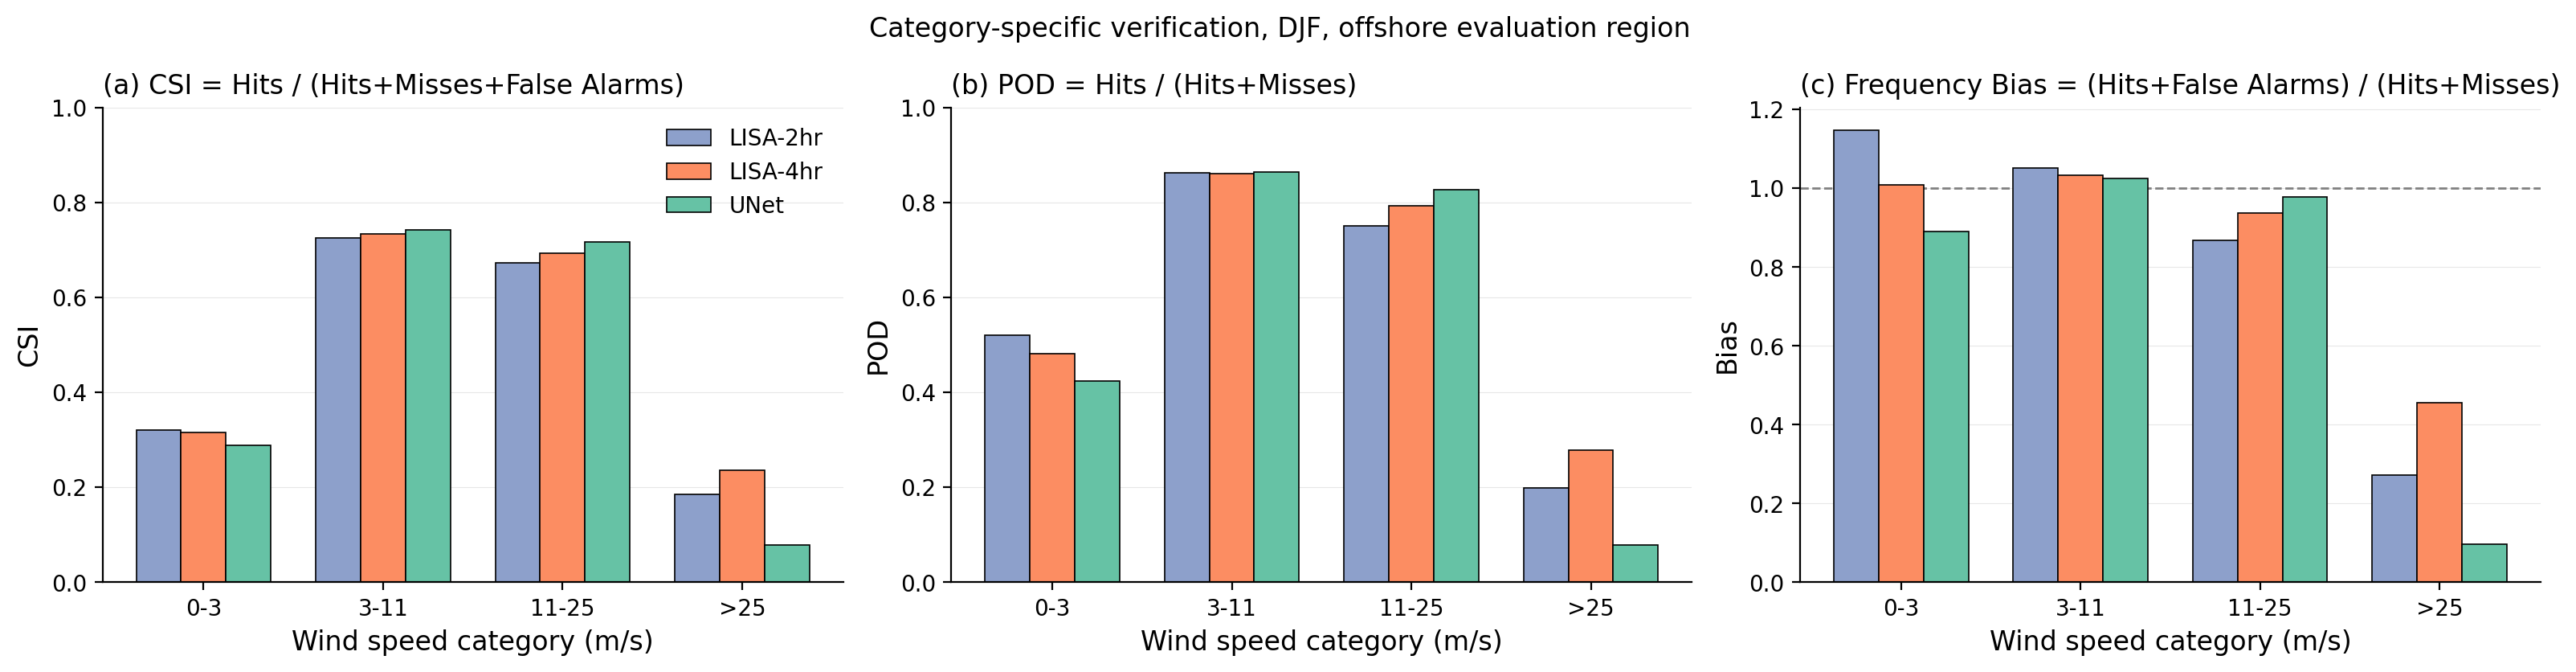

In [8]:
# Figure: CSI, POD, and Frequency Bias by wind speed category, one bar
# group per experiment (ANN season). The combined accuracy score
# (~0.81-0.85 across experiments) masks the fact that skill collapses
# (and the model under-forecasts, Bias << 1) in the >25 m/s category,
# shaded red below.
ann = verification_df[verification_df['season'] == 'DJF']
# ColorBrewer Set2 - colorblind-safe, lighter/softer than Okabe-Ito, common in journal figures.
colors = {'lisa3.1': '#8da0cb', 'lisa3.1_4hr': '#fc8d62', 'unet': '#66c2a5'}
labels = {'lisa3.1': 'LISA-2hr', 'lisa3.1_4hr': 'LISA-4hr', 'unet': 'UNet'}
width = 0.25
x = np.arange(len(category_order))

panel_titles = {
    'CSI': '(a) CSI = Hits / (Hits+Misses+False Alarms)',
    'POD': '(b) POD = Hits / (Hits+Misses)',
    'Bias': '(c) Frequency Bias = (Hits+False Alarms) / (Hits+Misses)',
}

mpl.rcParams['font.family'] = 'Helvetica'

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))
for metric, ax in zip(['CSI', 'POD', 'Bias'], axs):
    # ax.axvspan(x[-1] - 0.5, x[-1] + 0.5, color='red', alpha=0.08, zorder=0)
    if metric == 'Bias':
        ax.axhline(1.0, color='gray', linewidth=1.0, linestyle='--', zorder=1)
    for i, expr in enumerate(expr_order):
        sub = ann[ann['expr'] == expr].set_index('category').loc[category_order]
        ax.bar(x + (i - 1) * width, sub[metric], width=width, label=labels[expr],
               color=colors[expr], edgecolor='black', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(category_order)
    ax.set_xlabel('Wind speed category (m/s)', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    if metric != 'Bias':
        ax.set_ylim(0, 1)
    ax.set_title(panel_titles[metric], loc='left', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.grid(True, linewidth=0.4, alpha=0.3)
    ax.set_axisbelow(True)

axs[0].legend(fontsize=10, loc='upper right', frameon=False)
fig.suptitle('Category-specific verification, DJF, offshore evaluation region', fontsize=12)
plt.tight_layout()
plt.savefig('figure_categorical_verification_DJF.png', dpi=300, bbox_inches='tight')
plt.show()

## Comment 3

> It would be interesting to add some snapshots of the downscaled winds using all three data-driven models, ERA5, and HRRR for a given timestep. The scores are important, but comparing instantaneous predictions and error structures is also informative because it can reveal biases. There are only aggregated scores aside from Figure 4 — a couple of instantaneous snapshots in the main text (or supporting information) would be informative.

**Strategy:** use the hour of peak domain-wide HRRR wind speed within each of the 6 already-documented wind events (Downslope/AR/LLJ × Morro/Humboldt). Each event has a distinct meteorological regime, and peak-wind hours are the most scientifically relevant for energy applications. ERA5 is shown at its native 0.25° resolution to preserve the resolution contrast honestly.

Pre-computed peak HRRR timestamps (from `ground_truth/pred.gt.nc`, domain max):

| Event | Peak time | HRRR max (m/s) |
|---|---|---|
| Downslope / Morro | 2020-11-18 00:00 | 46.86 |
| Downslope / Humboldt | 2020-11-27 08:00 | 37.42 |
| AR / Morro | 2020-12-15 21:00 | 34.08 |
| AR / Humboldt | 2020-12-22 14:00 | 37.07 |
| LLJ / Morro | 2021-05-08 08:00 | 39.15 |
| LLJ / Humboldt | 2021-07-22 01:00 | 23.61 |

In [10]:
import pandas as pd

# Peak-wind hour per event (pre-computed: hour of max domain HRRR wind speed)
events_info = [
    ('Downslope / Morro',    '2020-11-18 00:00'),
    ('Downslope / Humboldt', '2020-11-27 08:00'),
    ('AR / Morro',           '2020-12-15 21:00'),
    ('AR / Humboldt',        '2020-12-22 14:00'),
    ('LLJ / Morro',          '2021-05-08 08:00'),
    ('LLJ / Humboldt',       '2021-07-22 01:00'),
]

# Lazy-load all model outputs (data selected at plot time to keep memory low)
era5_sfc = xr.open_dataset('/global/cfs/cdirs/m4506/yeliu/ERA/uvp.sfc.2019_2022.nc')
gt_da    = xr.open_dataarray('ground_truth/pred.gt.nc').drop_duplicates('time')
lisa2_da = xr.open_dataarray('results_v3.1/pred.lisa3.1.nc').drop_duplicates('time')
lisa4_da = xr.open_dataarray('results_v3.1_4hr/pred.lisa3.1_4hr.nc').drop_duplicates('time')
unet_da  = xr.open_dataarray('results_unet/pred.unet.nc').drop_duplicates('time')

# Model grid lat/lon from the ground-truth DataArray (same grid for all model outputs)
model_lat = gt_da['lat'].values                    # (670, 260), degrees N
model_lon = gt_da['lon'].values - 360.0            # (670, 260), convert 0..360 → -180..180

print("Model grid shape:", model_lat.shape)
print("Model lon range:", model_lon.min().round(1), model_lon.max().round(1))
print("ERA5 time:", str(era5_sfc.time.values[0])[:13], '..', str(era5_sfc.time.values[-1])[:13])

Model grid shape: (670, 260)
Model lon range: -132.1 -116.8
ERA5 time: 2019-01-01T00 .. 2022-12-31T23


In [11]:
def plot_on_map(data, u=None, v=None, **kwargs):
    mpl.rcParams['font.size'] = 15
    mpl.rcParams['font.family'] = 'Helvetica'  
    
    # create a figure
    if (fig:=kwargs.get('fig')) is None:  
        fig = plt.figure(figsize=(8, 5))
    if (ax:=kwargs.get('ax')) is None:  ax = plt.axes()
    ax.set_axis_on()
    
    # set map - extent, grid, coastline ...
    plot_map.set_map(
        ax,
        extent=kwargs.get('extent',[-125+360,-70+360,24,50]),
        # extent=[0,360,15,90],
        gridlines_kw=dict(
            xticks=[-130,-125,-120],
            yticks=[30,35,40,45],
            linestyle=":", alpha=0.3,
        ),
        gridlabels_kw=dict(
            xticks=[-130,-125,-120] if kwargs.get('drawxticks', False) else [],
            yticks=[30,35,40,45] if kwargs.get('drawyticks', False) else [],
        ),
        boundary_kw=dict(
            draw_state=True,
            coastline_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
            draw_borders=True,
            border_kw=dict(linewidth=0.9, alpha=0.7, color='k'),
        ),
    )
    
    # lat and lon for contour plot
    if ((lon:=kwargs.get('lon')) is None): lon = data['lon']
    if ((lat:=kwargs.get('lat')) is None): lat = data['lat']
        
    # draw contourf
    cmap = kwargs.get('cmap', "WhiteBlueGreenYellowRed")
    clev = kwargs.get('clev', np.arange(0, 40, 1))
    # cs, clev = plot_map.add_contourf(
    cs, clev = plot_map.add_pcolormesh(
        ax, lon, lat, data,
        # cmap=cm_wind['cmap'],clev=clev,
        cmap=cmap,clev=clev,
    )
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.25,0.5,0.75,1], colors='k', zorder=10)        
    # plot_map.add_contour(ax, lon, lat, data, clev=[0, 0.1,0.2,0.3,0.4,0.5,0.75,1], colors='k', zorder=10)        
    
    # cs = ax.contourf(lon, lat, data, cmap=cm_wind['cmap'], norm=cm_wind['norm'], clev=clev)
    if (u is not None) & (v is not None):
        d = 20
        _lat = lat[::d,::d]
        _lon = lon[::d,::d]
        # uu, vv = rotate_wind(u[::d,::d], v[::d,::d], _lon)
        uu, vv = u[::d,::d], v[::d,::d]
        vec = plot_map.add_vector(ax,
            _lon, _lat, uu, vv,
            vector_kwargs=dict(
                scale_units="inches", scale=kwargs.get('vector_scale',30),
            )
        )
        rect = mpl.patches.Rectangle(
            (0., 0),  # (x, y)
            0.25,  # width
            0.1,  # height
            facecolor='white',
            edgecolor='gray',
            transform=ax.transAxes,
        )
        ax.add_patch(rect)
        ax.quiverkey(vec, 0.10, 0.05, 5, "5",labelpos='E', coordinates='axes')
    
    if (overlay:=kwargs.get('overlay')) is not None:
        plot_map.add_hatches(ax, lon, lat, overlay, clev=[0, 0.05], zorder=10)

        
    # add text - title, ananote
    if (title:=kwargs.get('title')) is not None: 
        default_title_kwargs = dict(loc='left')
        default_title_kwargs.update(kwargs.get('title_kwargs', {}))
        ax.set_title(title, **default_title_kwargs)

    if kwargs.get('draw_colorbar'):
        plot_map.add_colorbar(cs, ax, clev[1:-1])
        
    return cs, clev

In [12]:
import cmaps
from scipy.interpolate import griddata

# Column order: HRRR | ERA5 (0.25°) | LISA-2hr | LISA-4hr | UNet
col_labels = ['HRRR', 'ERA5 (0.25°)', 'LISA-2hr', 'LISA-4hr', 'UNet']
model_das  = [gt_da, lisa2_da, lisa4_da, unet_da]   # index → col 0, 2, 3, 4

map_extent = [235.2, 238.2, 29.721663, 48.909824]
projection = ccrs.LambertConformal(central_longitude=-97.7)
_clev      = np.arange(0, 35, 1)

mpl.rcParams['font.family'] = 'Helvetica'
mpl.rcParams['font.size']   = 9

offshore_mask_bool = (offshore_mask.values == 1)  # (670, 260)

# Regrid offshore mask onto ERA5 grid once (nearest-neighbor, binary mask)
_model_pts          = np.column_stack([model_lon.ravel(), model_lat.ravel()])
_era5_lon2d, _era5_lat2d = np.meshgrid(era5_sfc.longitude.values, era5_sfc.latitude.values)
era5_mask_bool = griddata(
    _model_pts, offshore_mask_bool.ravel().astype(float),
    (_era5_lon2d, _era5_lat2d), method='nearest',
) > 0.5


def _panel_stats(comp_2d, ref_2d):
    """Mean bias and Pearson r over valid (non-NaN) points."""
    c, r = comp_2d.ravel(), ref_2d.ravel()
    valid = ~np.isnan(c) & ~np.isnan(r)
    bias  = float(np.mean(c[valid] - r[valid]))
    corr  = float(np.corrcoef(c[valid], r[valid])[0, 1])
    return bias, corr


def plot_snapshot_figure(events_subset, outfile):
    """2-row x 5-column snapshot figure for a pair of wind events.
    Column order: HRRR | ERA5 (0.25°) | LISA-2hr | LISA-4hr | UNet
    Non-HRRR panels annotated with mean bias and spatial correlation vs HRRR.
    """
    fig, axs = plt.subplots(
        2, 5, figsize=(10, 8),
        subplot_kw={'projection': projection},
    )
    axs_flat = axs.ravel()

    for i, (event_name, peak_str) in enumerate(events_subset):
        peak_time = pd.Timestamp(peak_str)
        snaps   = [da.sel(time=peak_time, method='nearest') for da in model_das]
        era5_t  = era5_sfc.sel(time=peak_time, method='nearest')
        era5_ws = np.sqrt(era5_t['u100'].values**2 + era5_t['v100'].values**2)
        era5_ws_masked = np.where(era5_mask_bool, era5_ws, np.nan)

        # Reference arrays for statistics (computed once per event)
        hrrr_offshore = np.where(offshore_mask_bool, snaps[0].values, np.nan)  # model grid
        hrrr_on_era5  = np.where(                                               # ERA5 grid
            era5_mask_bool,
            griddata(_model_pts, snaps[0].values.ravel(),
                     (_era5_lon2d, _era5_lat2d), method='nearest'),
            np.nan,
        )

        for j in range(5):
            ax        = axs_flat[i * 5 + j]
            is_left   = (j == 0)
            is_bottom = (i == 1)

            # j=0 HRRR → snaps[0]  | j=1 ERA5 (different grid)
            # j=2 LISA-2hr → snaps[1] | j=3 LISA-4hr → snaps[2] | j=4 UNet → snaps[3]
            if j == 0:
                data = hrrr_offshore
                lon, lat = model_lon, model_lat
            elif j == 1:
                data = era5_ws_masked
                lon  = era5_sfc.longitude.values
                lat  = era5_sfc.latitude.values
            else:
                data = np.where(offshore_mask_bool, snaps[j - 1].values, np.nan)
                lon, lat = model_lon, model_lat

            cs, _ = plot_on_map(
                data, fig=fig, ax=ax, lon=lon, lat=lat,
                extent=map_extent,
                cmap='WhiteBlueGreenYellowRed', clev=_clev,
                drawxticks=is_bottom, drawyticks=is_left,
            )

            ax.set_title(col_labels[j], fontsize=11)

            # Bias and spatial correlation vs HRRR (skip HRRR panel itself)
            if j > 0:
                ref  = hrrr_on_era5 if j == 1 else hrrr_offshore
                bias, corr = _panel_stats(data, ref)
                ax.text(
                    0.03, 0.04,
                    f"Bias: {bias:+.2f} m/s\nr = {corr:.3f}",
                    transform=ax.transAxes, fontsize=8,
                    va='bottom', ha='left', clip_on=False,
                    bbox=dict(facecolor='white', alpha=0.75, pad=2, edgecolor='none'),
                )

        # Horizontal row title above the leftmost panel
        row_label = f"{event_name} ({peak_str[:13]} UTC)"
        axs_flat[i * 5].text(
            0.0, 1.08, row_label,
            transform=axs_flat[i * 5].transAxes,
            fontsize=11, va='bottom', ha='left', fontweight='bold',
            clip_on=False,
        )

    cb = plot_map.add_colorbar(cs, axs, _clev[1:-1:5], pad=0.02, shrink=0.8, aspect=20, orientation='vertical')
    cb.ax.tick_params(labelsize=8)
    cb.set_label('Wind speed (m s$^{-1}$)', fontsize=11)

    plt.savefig(outfile, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {outfile}')

(1.0, 0.0)


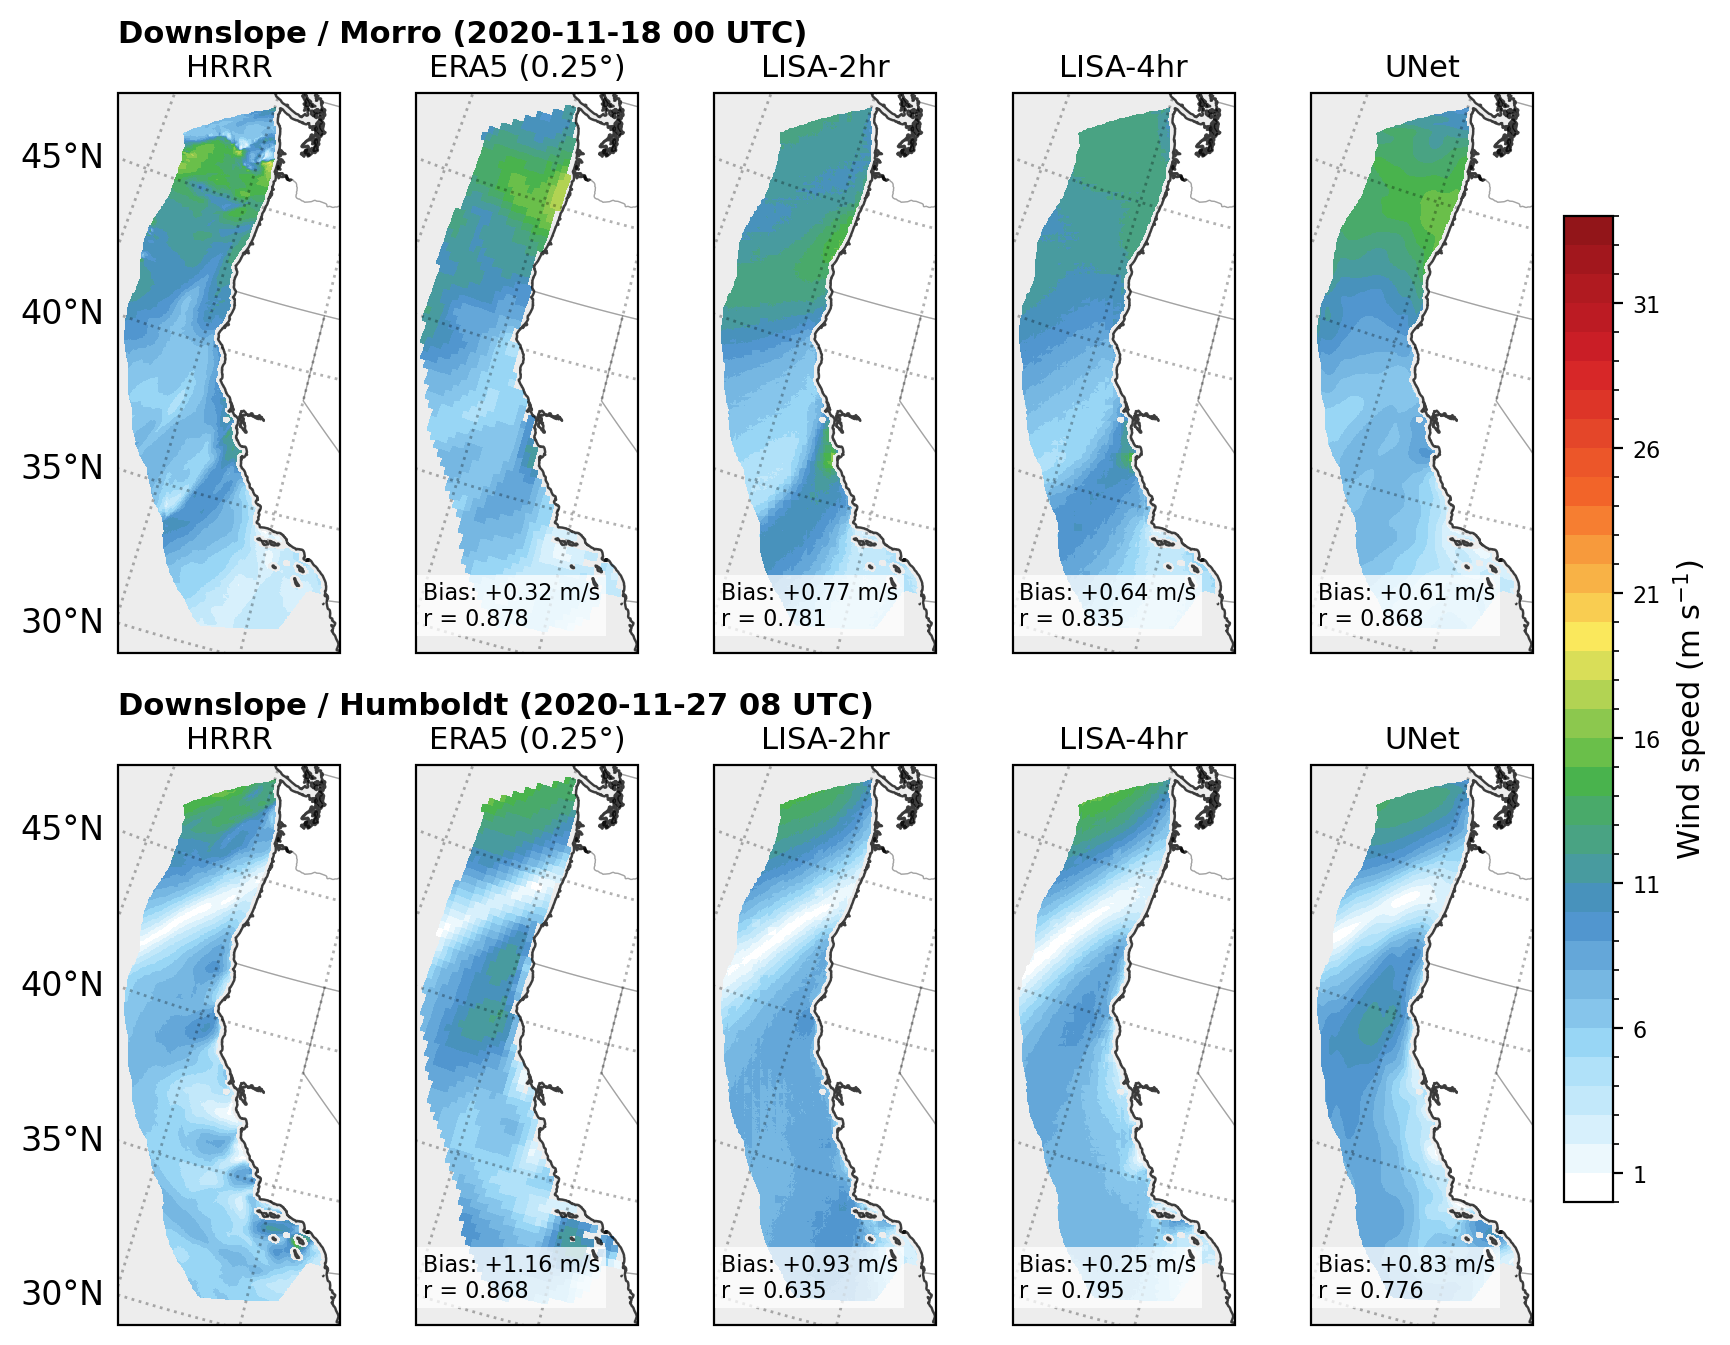

Saved: figure_snapshots_downslope.png


In [13]:
# Downslope events (events_info[0:2])
plot_snapshot_figure(events_info[0:2], 'figure_snapshots_downslope.png')

(1.0, 0.0)


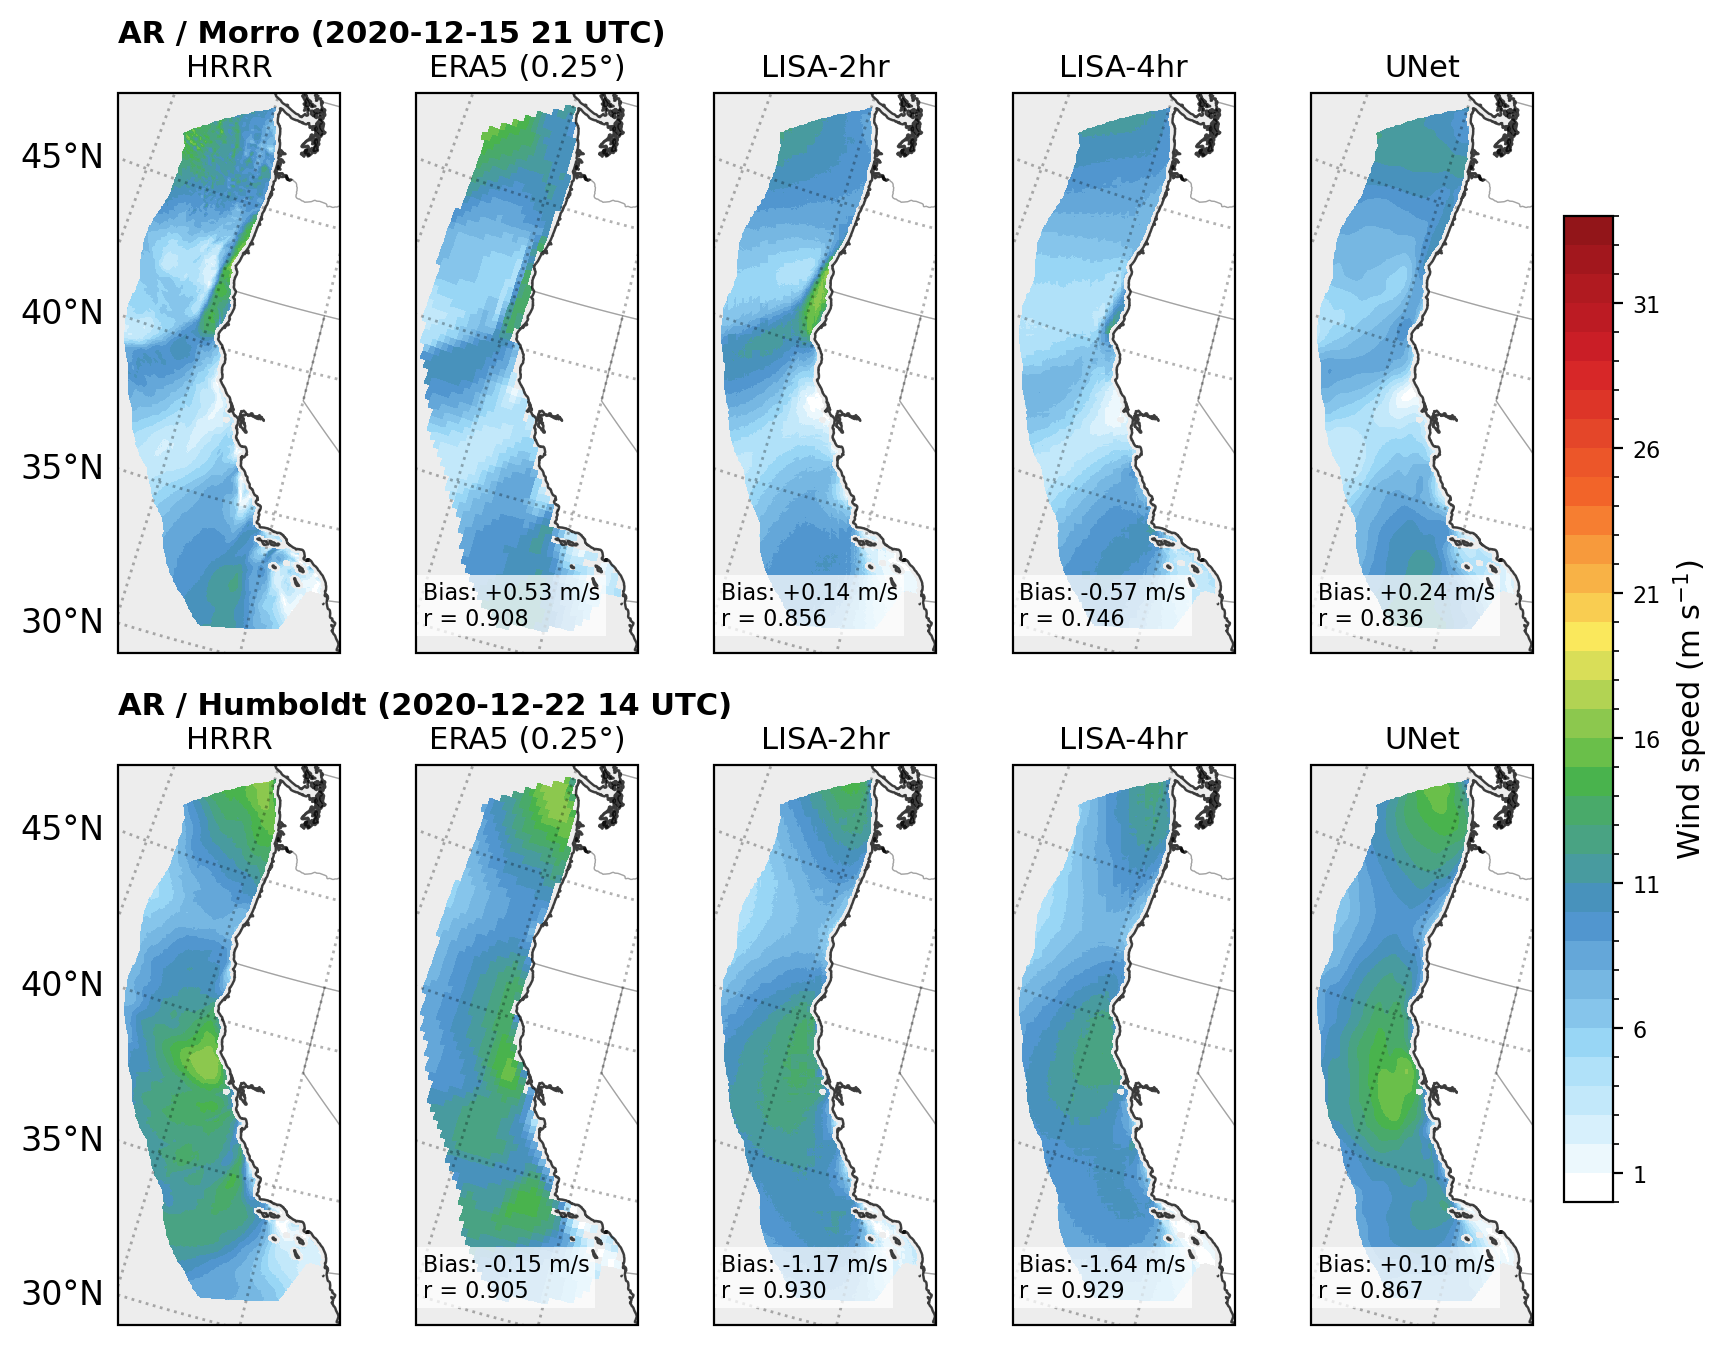

Saved: figure_snapshots_ar.png


In [14]:
# AR events (events_info[2:4])
plot_snapshot_figure(events_info[2:4], 'figure_snapshots_ar.png')

(1.0, 0.0)


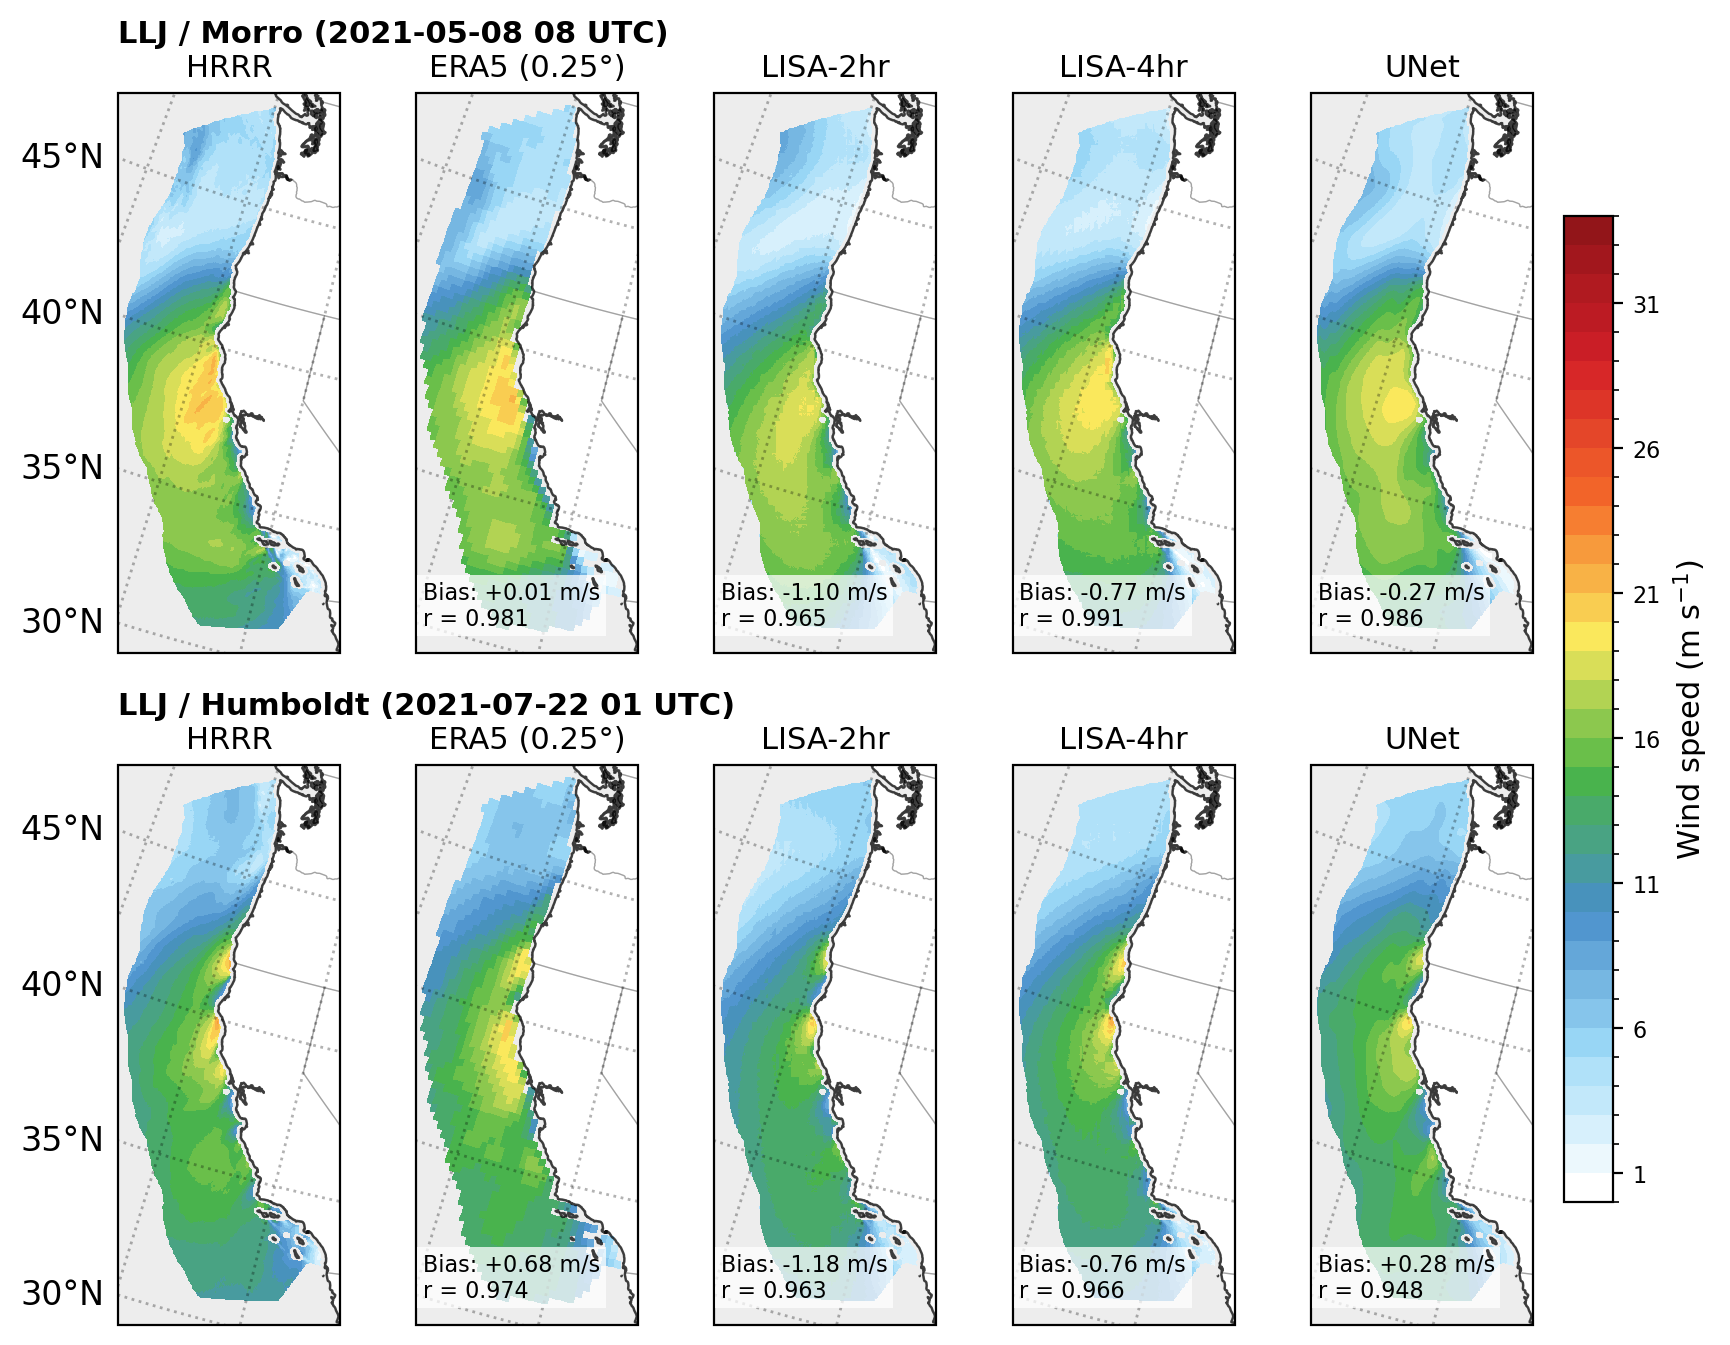

Saved: figure_snapshots_llj.png


In [15]:
# LLJ events (events_info[4:6])
plot_snapshot_figure(events_info[4:6], 'figure_snapshots_llj.png')